# Exploratory RNA-seq analysis report

This notebook summarizes a compact RNA-seq analysis from a `13`-sample subset spanning two individuals and multiple cortical layers. The focus here is not on making oversized claims; it is on showing that the data are coherent, that sample-level structure is visible, and that the differential-expression screen produces a reasonable set of candidates for follow-up.

All figures are generated directly from the result tables included with the project, so the report is reproducible and easy to inspect.


## Report structure

- verify the result bundle
- summarize the subset used for analysis
- inspect QC and sample-level structure
- review the exploratory differential-expression output


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Try the env var first, then look around the repo a bit.
# This keeps the notebok portable without baking in personal paths.
candidate_paths = []
env_path = os.environ.get("RNASEQ_RESULT_DIR")
if env_path:
    candidate_paths.append(Path(env_path))

search_roots = [Path.cwd(), *list(Path.cwd().parents)[:3], Path.home()]
for root in search_roots:
    candidate_paths.append(root / "results")

seen = set()
candidate_paths = [p for p in candidate_paths if not (str(p) in seen or seen.add(str(p)))]
RESULT_DIR = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
display(Markdown("**Result bundle located.**"))


**Result bundle located.**

## Data bundle check

The analysis only needs three tabular files: the merged count matrix, the sample metadata table, and the differential-expression summary. Existing PNGs are left in place as references, but the report does not depend on them.


In [2]:
required_files = {
    "merged_counts": RESULT_DIR / "merged_counts.tsv",
    "sample_metadata": RESULT_DIR / "sample_metadata.tsv",
    "de_results": RESULT_DIR / "de_results.tsv",
}
optional_files = {
    "qc_histograms_png": RESULT_DIR / "plots" / "qc_histograms.png",
    "sample_correlation_heatmap_png": RESULT_DIR / "plots" / "sample_correlation_heatmap.png",
    "pca_png": RESULT_DIR / "plots" / "pca.png",
    "volcano_png": RESULT_DIR / "plots" / "volcano_ancova.png",
}

file_status = pd.DataFrame(
    [
        {
            "artifact": name,
            "exists": path.exists(),
            "required": name in required_files,
            "size_kb": round(path.stat().st_size / 1024, 1) if path.exists() else None,
        }
        for name, path in {**required_files, **optional_files}.items()
    ]
)

display(file_status)

missing_required = file_status.loc[file_status["required"] & ~file_status["exists"], "artifact"].tolist()
if missing_required:
    raise FileNotFoundError(f"Missing required result files: {missing_required}")


,artifact,exists,required,size_kb
0,merged_counts,True,True,2985.4
1,sample_metadata,True,True,0.4
2,de_results,True,True,1292.7
3,qc_histograms_png,True,False,27.8
4,sample_correlation_heatmap_png,True,False,30.8
5,pca_png,True,False,49.7
6,volcano_png,True,False,62.6


## Input tables

These tables define the rest of the notebook: one for sample annotation, one for gene-level counts, and one for the exploratory gene-ranking step.


In [3]:
sample_metadata = pd.read_csv(required_files["sample_metadata"], sep="	")
merged_counts_raw = pd.read_csv(required_files["merged_counts"], sep="	")
de_results = pd.read_csv(required_files["de_results"], sep="	")

counts = merged_counts_raw.set_index("gene_id")
sample_order = sample_metadata["Sample"].tolist()
counts = counts.loc[:, sample_order]

summary = pd.DataFrame(
    {
        "metric": [
            "samples",
            "individuals",
            "layers",
            "genes in merged matrix",
            "genes tested in DE step",
            "genes flagged in DE screen",
        ],
        "value": [
            sample_metadata.shape[0],
            sample_metadata["Individual"].nunique(),
            sample_metadata["Layer"].nunique(),
            counts.shape[0],
            de_results.shape[0],
            int(de_results.get("DE", pd.Series(dtype=bool)).fillna(False).sum()),
        ],
    }
)

display(summary)


,metric,value
0,samples,13
1,individuals,2
2,layers,7
3,genes in merged matrix,61852
4,genes tested in DE step,21755
5,genes flagged in DE screen,5


## Cohort snapshot

The current subset contains `13` samples drawn from two individuals and multiple cortical layers. That is enough to make the structure plots useful, although the design is still a bit uneven because one sample is missing. I would treat this as a credible exploratory subset, not a final balanced cohort.


In [4]:
display(sample_metadata)

layer_counts = sample_metadata["Layer"].value_counts().sort_index().rename_axis("Layer").reset_index(name="n_samples")
individual_counts = sample_metadata["Individual"].value_counts().sort_index().rename_axis("Individual").reset_index(name="n_samples")

display(layer_counts)
display(individual_counts)


,Run,Sample,Individual,Layer
0,SRR2815952,DS1_H1_01,DS1_H1,L1
1,SRR2815954,DS1_H1_03,DS1_H1,L2
2,SRR2815957,DS1_H1_06,DS1_H1,L3
3,SRR2815958,DS1_H1_07,DS1_H1,L4
4,SRR2815961,DS1_H1_10,DS1_H1,L5
5,SRR2815964,DS1_H1_13,DS1_H1,L6
6,SRR2815969,DS1_H1_18,DS1_H1,WM
7,SRR2815970,DS1_H2_01,DS1_H2,L1
8,SRR2815971,DS1_H2_02,DS1_H2,L2
9,SRR2815975,DS1_H2_06,DS1_H2,L3


,Layer,n_samples
0,L1,2
1,L2,2
2,L3,2
3,L4,2
4,L5,2
5,L6,1
6,WM,2


,Individual,n_samples
0,DS1_H1,7
1,DS1_H2,6


## Processing choices

Before plotting, the matrix is filtered lightly to remove genes with little information, then transformed to log space for the similarity and PCA views. The choices here are intentionally simple so the figures stay easy to explain.


In [5]:
avg_expr = counts.mean(axis=1)
num_detected = (counts > 0).sum(axis=1)

# Keep the filtering pretty light so we dont throw away too much signal.
expressed = ((counts > 0).mean(axis=1) >= 0.5) | (counts.mean(axis=1) >= 1)
analysis_counts = counts.loc[expressed].copy()
analysis_counts = analysis_counts.loc[analysis_counts.std(axis=1) > 0]

# Log space usually makes the sample-to-sample shape easier to read.
log_counts = np.log1p(analysis_counts)

corr = log_counts.corr(method="spearman")
u, s, vt = np.linalg.svd(log_counts.T - log_counts.T.mean(axis=0), full_matrices=False)
scores = u * s
variance_ratio = (s ** 2) / np.sum(s ** 2)

layer_palette = {
    layer: color
    for layer, color in zip(sorted(sample_metadata["Layer"].unique()), plt.cm.tab10.colors)
}
individual_markers = {
    individual: marker
    for individual, marker in zip(sorted(sample_metadata["Individual"].unique()), ["o", "s", "^", "D", "P", "X"])
}

display(pd.DataFrame({"filtered_genes": [analysis_counts.shape[0]], "samples": [analysis_counts.shape[1]]}))


,filtered_genes,samples
0,21755,13


## Result 1: expression and detection profiles

These histograms give a broad read on the matrix. The left panel shows the spread of average expression across genes, while the right panel shows how widely each gene is detected across the subset. In practice, this is mostly a sanity check that the dataset has usable dynamic range and is not collapsing into a sparse edge case.


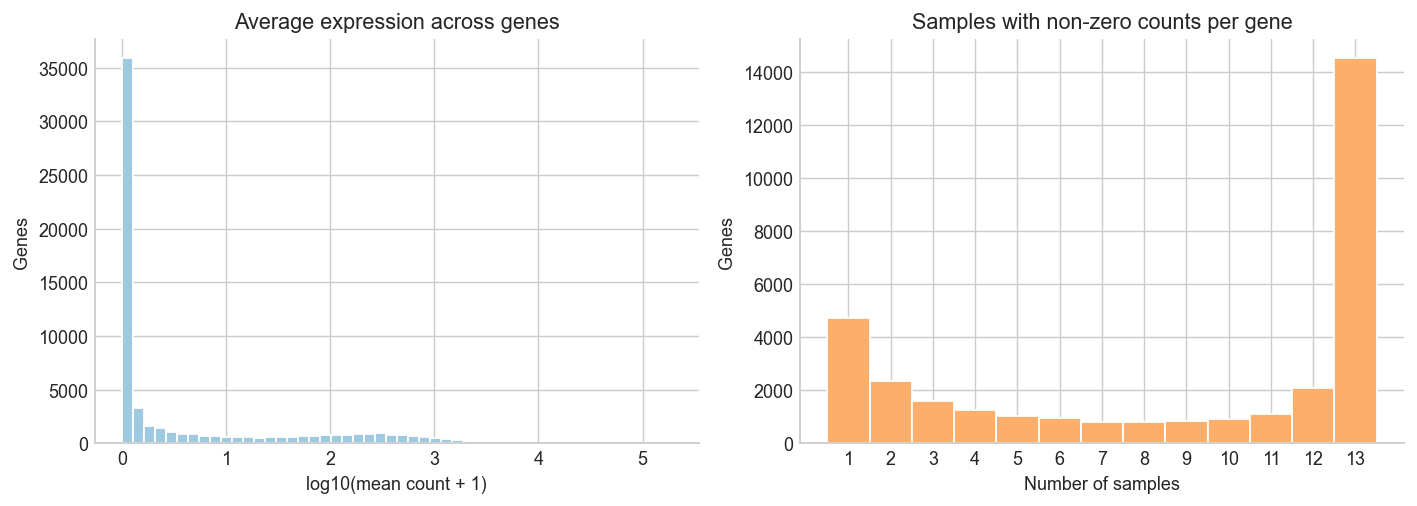

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(avg_expr + 1), bins=50, color="#9ecae1", edgecolor="white")
axes[0].set_title("Average expression across genes")
axes[0].set_xlabel("log10(mean count + 1)")
axes[0].set_ylabel("Genes")

axes[1].hist(num_detected, bins=range(1, counts.shape[1] + 2), color="#fdae6b", edgecolor="white", align="left")
axes[1].set_title("Samples with non-zero counts per gene")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Genes")
axes[1].set_xticks(range(1, counts.shape[1] + 1))

plt.tight_layout()
plt.show()


## Result 2: sample similarity

The correlation heatmap summarizes how similar the samples are after filtering and log transformation. If this figure looked chaotic, that would be a problem. Instead, it serves as a quick visual check that the samples share real structure and that no single profile is obviously derailing the analysis.


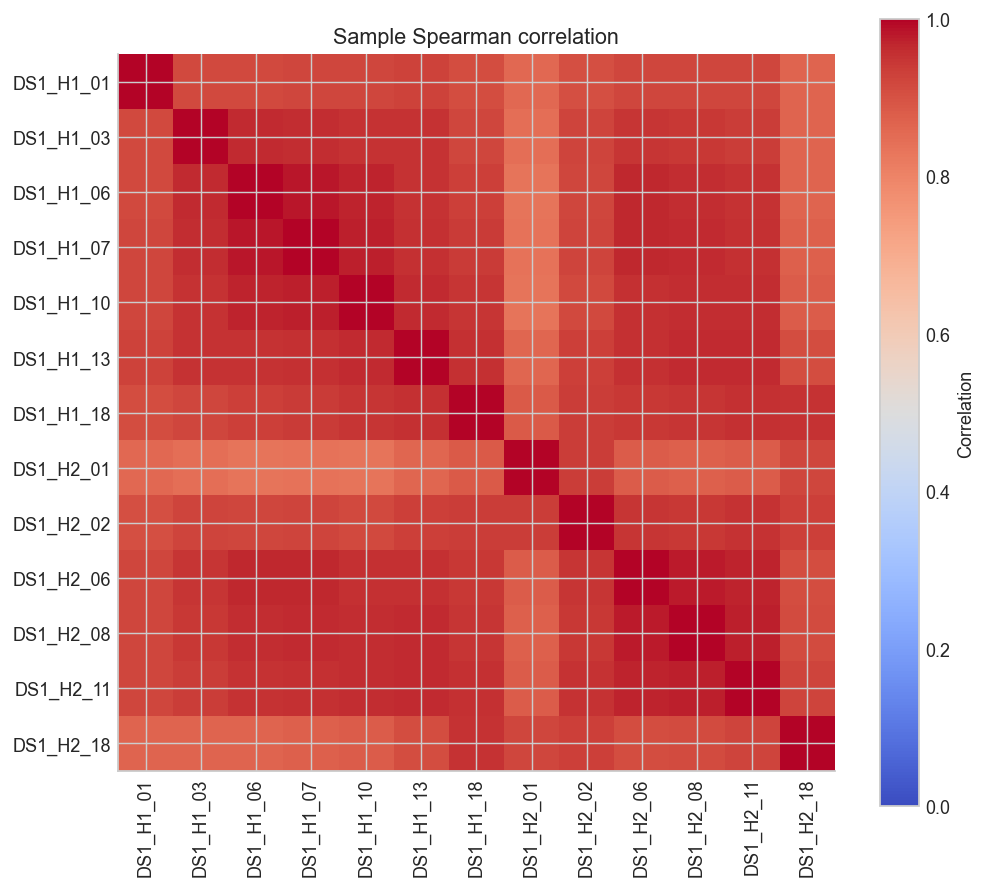

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=0, vmax=1)
ax.set_xticks(range(corr.shape[1]))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(corr.shape[0]))
ax.set_yticklabels(corr.index)
ax.set_title("Sample Spearman correlation")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")
plt.tight_layout()
plt.show()


## Result 3: dominant structure by PCA

PCA compresses the high-dimensional expression matrix into the main axes of variation. This is usually the clearest figure for discussing whether the subset contains interpretable structure rather than just noise. Nearby points reflect samples with more similar overall transcriptional profiles.


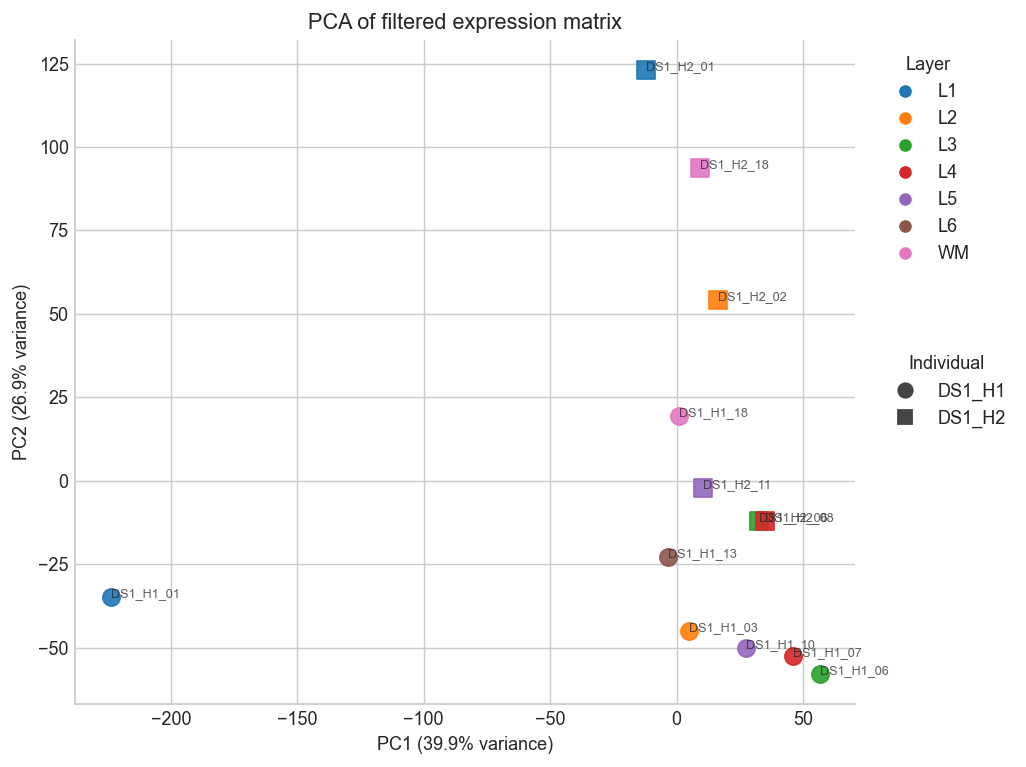

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in sample_metadata.iterrows():
    idx = sample_order.index(row["Sample"])
    ax.scatter(
        scores[idx, 0],
        scores[idx, 1],
        color=layer_palette[row["Layer"]],
        marker=individual_markers[row["Individual"]],
        s=90,
        alpha=0.9,
    )
    ax.text(scores[idx, 0], scores[idx, 1], row["Sample"], fontsize=7, alpha=0.75)

ax.set_xlabel(f"PC1 ({variance_ratio[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({variance_ratio[1] * 100:.1f}% variance)")
ax.set_title("PCA of filtered expression matrix")

layer_handles = [plt.Line2D([0], [0], marker="o", color="w", label=layer, markerfacecolor=color, markersize=8) for layer, color in layer_palette.items()]
individual_handles = [plt.Line2D([0], [0], marker=marker, color="#444444", label=individual, linestyle="None", markersize=8) for individual, marker in individual_markers.items()]

legend1 = ax.legend(handles=layer_handles, title="Layer", loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(legend1)
ax.legend(handles=individual_handles, title="Individual", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()


## Result 4: exploratory differential-expression view

The volcano plot is used here as a ranking view rather than a definitive test. The x-axis tracks effect size and the y-axis tracks adjusted significance. For readability, the displayed y-range is capped when a single extreem point would otherwise flatten the full distribution.


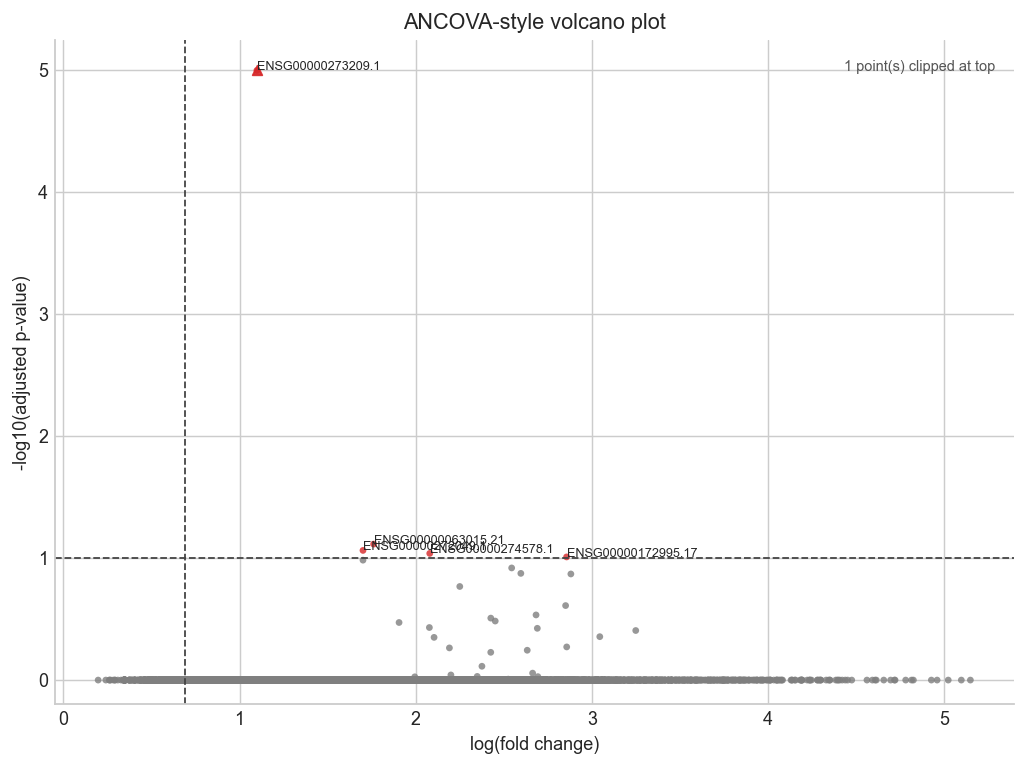

In [9]:
volcano = de_results.copy()
volcano = volcano.replace([np.inf, -np.inf], np.nan)
volcano = volcano.dropna(subset=["fc", "padj"])
volcano = volcano[(volcano["fc"] > 0) & (volcano["padj"] > 0)].copy()

volcano["log_fc"] = np.log(volcano["fc"])
volcano["neglog10_padj"] = -np.log10(volcano["padj"])

# One very tall point can squash the whole figure, so cap the display range a bit.
display_cap = max(5.0, float(volcano["neglog10_padj"].quantile(0.995)))
volcano["y_plot"] = volcano["neglog10_padj"].clip(upper=display_cap)
clipped = volcano["neglog10_padj"] > display_cap

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    volcano["log_fc"],
    volcano["y_plot"],
    c=np.where(volcano.get("DE", False), "#d62728", "#7f7f7f"),
    s=14,
    alpha=0.8,
    linewidths=0,
)

if clipped.any():
    ax.scatter(
        volcano.loc[clipped, "log_fc"],
        np.full(clipped.sum(), display_cap),
        marker="^",
        c="#d62728",
        s=28,
        alpha=0.9,
    )

ax.axvline(np.log(2), color="#444444", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.1), color="#444444", linestyle="--", linewidth=1)
ax.set_xlabel("log(fold change)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("ANCOVA-style volcano plot")
ax.set_ylim(-0.2, display_cap * 1.05)

# Only label a few points that are actaully informative on the plot.
label_pool = volcano.loc[volcano.get("DE", False)].copy()
if label_pool.empty:
    label_pool = volcano.loc[volcano["neglog10_padj"] > 1].copy()
if label_pool.empty:
    label_pool = volcano.copy()

top_hits = label_pool.nsmallest(min(5, len(label_pool)), "padj")
for _, row in top_hits.iterrows():
    ax.text(row["log_fc"], min(row["neglog10_padj"], display_cap), row["gene_id"], fontsize=7)

if clipped.any():
    ax.text(
        0.98,
        0.97,
        f"{int(clipped.sum())} point(s) clipped at top",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="#555555",
    )

plt.tight_layout()
plt.show()


## Main takeaways

- The subset is large enough to support clear QC, correlation, and PCA-based inspection.
- Sample-to-sample structure is visible, which argues that the count matrix is carrying real biological signal rather than only technical noise.
- The differential-expression panel works best as a shortlist of candidate genes to inspect further, not as a final inferential result.

The main limitation is straightforward: this is a `13`-sample subset so the design is not perfectly balanced. That does not invalidate the exploratory analysis but it does mean the biological interpretation should stay measured.
